# Homework 06 - Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Dataset
In this homework, we continue using the fuel efficiency dataset.
Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [3]:
# List of columns  
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

## Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

### Fill the missing values

In [4]:
# Sum of null values in each column
def list_null_values(df):
    return df.isnull().sum()

In [5]:
# Function to fill missing values with a value
def fill_null_values(df, cat_fill_value, num_fill_value):
    cat_columns = df.select_dtypes(include=['object']).columns
    num_columns = df.select_dtypes(include=['int64','float64']).columns
    
    # Fill NaNs for categorical columns with the provided value
    df[cat_columns] = df[cat_columns].fillna(cat_fill_value)
    
    # Fill NaNs for numerical columns with the provided value
    df[num_columns] = df[num_columns].fillna(num_fill_value)
    
    return df

In [6]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
list_null_values(df)

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df =fill_null_values(df=df, cat_fill_value='NA', num_fill_value=0.0)
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,0.0,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,0.0,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,0.0,15.101802
9700,180,0.0,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [9]:
list_null_values(df)

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

### Train/validation/test split with 60%/20%/20% distribution
* Use the `train_test_split` function and set the `random_state` parameter to 1.

In [10]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
len(df_full_train), len(df_test)

(7763, 1941)

In [11]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(5822, 1941)

In [12]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [13]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [14]:
# Remove the 'fuel_efficiency_mpg' variable from the dataframes
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

### Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [16]:
train_dicts = df_train.to_dict(orient='records')
val_dicts=df_val.to_dict(orient='records')

In [17]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val=dv.fit_transform(val_dicts)

In [18]:
feature_names=list(dv.get_feature_names_out())
feature_names

['acceleration',
 'drivetrain=All-wheel drive',
 'drivetrain=Front-wheel drive',
 'engine_displacement',
 'fuel_type=Diesel',
 'fuel_type=Gasoline',
 'horsepower',
 'model_year',
 'num_cylinders',
 'num_doors',
 'origin=Asia',
 'origin=Europe',
 'origin=USA',
 'vehicle_weight']

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* [x] `'vehicle_weight'`
* [ ]`'model_year'`
* [ ]`'origin'`
* [ ]`'fuel_type'`

In [19]:
dtr=DecisionTreeRegressor(max_depth=1)
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [20]:
print(export_text(dtr, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* [ ] 0.045
* [x] 0.45
* [ ] 4.5
* [ ] 45.0




In [21]:
rf = RandomForestRegressor(n_estimators=10,
                            random_state=1,
                           n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [22]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [23]:
y_pred =rf.predict(X_val)

In [24]:
rmse=rmse(y_val, y_pred)
rmse

0.4599777557336148

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- [ ] 10
- [ ] 25
- [ ] 80
- [x] 200

If it doesn't stop improving, use the latest iteration number in
your answer.




In [25]:
for i in range(10,200,10):
    rf = RandomForestRegressor(n_estimators=i,random_state=1,n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred =rf.predict(X_val)
    #rmse=round((rmse(y_val, y_pred)),3)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    #rmse=rmse(y_val, y_pred)
    print(f"{i}: {round(rmse,3)}")

10: 0.46
20: 0.454
30: 0.451
40: 0.448
50: 0.446
60: 0.445
70: 0.445
80: 0.445
90: 0.445
100: 0.444
110: 0.443
120: 0.444
130: 0.443
140: 0.443
150: 0.443
160: 0.443
170: 0.443
180: 0.442
190: 0.443


## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* [x] 10
* [ ] 15
* [ ] 20
* [ ] 25


In [26]:

rmses=[]

# max_depth
for i in [10, 15, 20, 25]:
    # n_estimators
    for j in range(10,200,10):
        rf = RandomForestRegressor(max_depth=i,n_estimators=j,random_state=1,n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred =rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(rmse)
    #rmses_mean=sum(rmses) / len(rmses)
    rmses_mean=np.mean(rmses)
    print(f"Max depth: {i} -> RMSE mean: {rmses_mean}")

Max depth: 10 -> RMSE mean: 0.44244650566770166
Max depth: 15 -> RMSE mean: 0.44382256929238034
Max depth: 20 -> RMSE mean: 0.4444796493267177
Max depth: 25 -> RMSE mean: 0.444814364157592


# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* [x] `vehicle_weight`
* [ ] `horsepower`
* [ ] `acceleration`
* [ ] `engine_displacement`	




In [27]:
rf = RandomForestRegressor(n_estimators=10,
                           max_depth=20,
                           random_state=1,
                           n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [28]:
# Access the feature importances
importances = list(rf.feature_importances_)
importances 

[0.011470716492980806,
 0.0003818097503064216,
 0.0003118420847931972,
 0.003269323417164296,
 0.0003436934113118486,
 0.0003366719883675566,
 0.016040214819390435,
 0.003182298414589243,
 0.002358670936092339,
 0.0015911330645071602,
 0.0004761030460744537,
 0.0005203580827405701,
 0.0005551519590829983,
 0.9591620125325987]

In [29]:
feature_names=list(dv.get_feature_names_out())
feature_names

['acceleration',
 'drivetrain=All-wheel drive',
 'drivetrain=Front-wheel drive',
 'engine_displacement',
 'fuel_type=Diesel',
 'fuel_type=Gasoline',
 'horsepower',
 'model_year',
 'num_cylinders',
 'num_doors',
 'origin=Asia',
 'origin=Europe',
 'origin=USA',
 'vehicle_weight']

                         Feature  Importance
13                vehicle_weight    0.959162
6                     horsepower    0.016040
0                   acceleration    0.011471
3            engine_displacement    0.003269
7                     model_year    0.003182
8                  num_cylinders    0.002359
9                      num_doors    0.001591
12                    origin=USA    0.000555
11                 origin=Europe    0.000520
10                   origin=Asia    0.000476
1     drivetrain=All-wheel drive    0.000382
4               fuel_type=Diesel    0.000344
5             fuel_type=Gasoline    0.000337
2   drivetrain=Front-wheel drive    0.000312


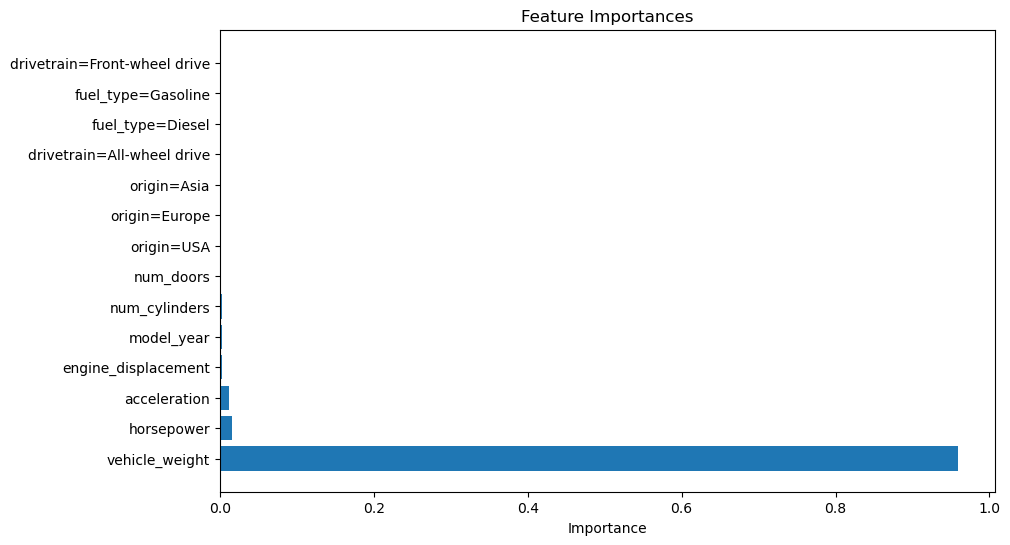

In [30]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Sort the features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value